In [46]:
import numpy as np
import h5py
import bacco
import matplotlib.pyplot as plt
import dask.array as dd


ModuleNotFoundError: No module named 'logger'

In [51]:
#def read_zoom():

base = "/cosmos_storage/data_sharing/tmp_resims/snapdir_000/"

files = ["snapshot_ics_000.{:d}.hdf5".format(ifile) for ifile in range(32)]

with h5py.File(base+files[0], 'r') as f:
    NpartTotal = np.uint64(f['Header'].attrs['NumPart_Total'])

pos1 = np.zeros((NpartTotal[1], 3), dtype=np.float32)
pos2 = np.zeros((NpartTotal[2], 3), dtype=np.float32)
pos3 = np.zeros((NpartTotal[3], 3), dtype=np.float32)

istart1 = np.uint64(0); istart2 = np.uint64(0); istart3 = np.uint64(0)
for ffname in files:
    with h5py.File(base+ffname, 'r') as f:
        npts1 = np.uint64(f['Header'].attrs['NumPart_ThisFile'][1])
        npts2 = np.uint64(f['Header'].attrs['NumPart_ThisFile'][2])
        npts3 = np.uint64(f['Header'].attrs['NumPart_ThisFile'][3])

        print(
            'Read data for {0}/{1} {1}/{2} {3}/{4} particles...'.format(
                istart1+npts1, NpartTotal[1], istart2+npts2, NpartTotal[2], istart3+npts3, NpartTotal[3]))

        if npts1 >0:
            pos1[istart1:istart1 + npts1] = f[u'PartType1']['Coordinates'][()]
        if npts2 >0:
            pos2[istart2:istart2 + npts2] = f[u'PartType2']['Coordinates'][()]
        if npts3 >0:
            pos3[istart3:istart3 + npts3] = f[u'PartType3']['Coordinates'][()]

    istart1 += npts1
    istart2 += npts2
    istart3 += npts3

#    return {'pos':pos}

Read data for 0/1439038 1439038/0 993829/324 particles...
Read data for 0/1439038 1439038/0 993829/802 particles...
Read data for 465026/1439038 1439038/255818 993829/47000 particles...
Read data for 465026/1439038 1439038/255818 993829/47177 particles...
Read data for 517002/1439038 1439038/368991 993829/79498 particles...
Read data for 517002/1439038 1439038/372772 993829/82872 particles...
Read data for 517002/1439038 1439038/372772 993829/83049 particles...
Read data for 517002/1439038 1439038/389676 993829/89895 particles...
Read data for 517002/1439038 1439038/391473 993829/95583 particles...
Read data for 632057/1439038 1439038/474093 993829/115845 particles...
Read data for 632057/1439038 1439038/474093 993829/116050 particles...
Read data for 632057/1439038 1439038/474093 993829/116668 particles...
Read data for 632057/1439038 1439038/474093 993829/116922 particles...
Read data for 632057/1439038 1439038/474093 993829/117078 particles...
Read data for 632057/1439038 1439038/47

In [36]:
zoom = read_zoom()

TypeError: only integer scalar arrays can be converted to a scalar index

Text(0, 0.5, '$y[$Mpc$/h]$')

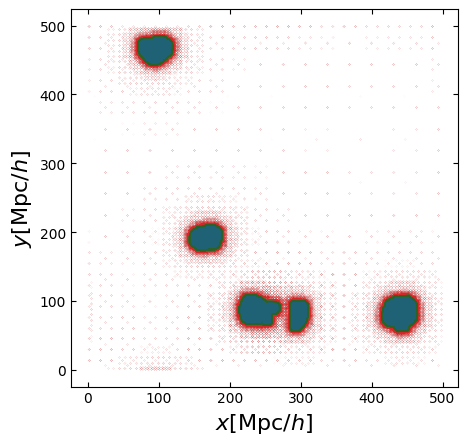

In [68]:
fig, ax = plt.subplots(dpi=100, figsize=(5,5))

ax.scatter(pos3[:,0], pos3[:,1], marker='.', s=0.0005, color='C3')
ax.scatter(pos2[:,0], pos2[:,1], marker='.', s=0.0005, color='C2')
ax.scatter(pos1[:,0], pos1[:,1], marker='.', s=0.0005, color='C0')

ax.set_xlabel('$x[$Mpc$/h]$', fontsize=16)
ax.set_ylabel('$y[$Mpc$/h]$', fontsize=16)

In [ ]:
fig, ax = plt.subplots(dpi=100, figsize=(5,5))

ax.scatter(pos3[:,0], pos3[:,1], marker='.', s=0.0005, color='C3')
ax.scatter(pos2[:,0], pos2[:,1], marker='.', s=0.0005, color='C2')
ax.scatter(pos1[:,0], pos1[:,1], marker='.', s=0.0005, color='C0')

ax.set_xlabel('$x[$Mpc$/h]$', fontsize=16)
ax.set_ylabel('$y[$Mpc$/h]$', fontsize=16)